In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import SVR


In [36]:
df =pd.read_csv("coklu_regresyon_veri.csv")
df = df.dropna()
df

,Yillik_Gelir_TL,Calisma_Yili,Egitim_Yili,Haftalik_Calisma_Saati,Yonetici_Puani,Performans_Skoru
0,509605,26,8,56,9,375.55
1,433408,2,16,49,5,289.32
2,527722,27,15,35,1,313.20
3,632763,24,9,48,10,397.79
4,421901,27,20,54,7,358.57
...,...,...,...,...,...,...
495,514669,14,15,30,2,278.37
496,325530,23,19,53,3,304.47
497,427159,17,20,59,7,326.37
498,344925,18,12,51,8,286.21


In [37]:
clf = LocalOutlierFactor(n_neighbors = 20, contamination = "auto")
df["df_hata"] = clf.fit_predict(df[["Calisma_Yili","Egitim_Yili","Haftalik_Calisma_Saati", "Yonetici_Puani", "Performans_Skoru", "Yillik_Gelir_TL"]])

In [38]:
temiz_df = df[df["df_hata"] == 1].drop("df_hata", axis=1)

In [39]:
df.shape

(500, 7)

In [40]:
temiz_df.shape

(491, 6)

In [41]:
x = temiz_df[["Calisma_Yili","Egitim_Yili","Haftalik_Calisma_Saati", "Yonetici_Puani", "Performans_Skoru"]]

In [42]:
y = temiz_df["Yillik_Gelir_TL"]

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x,y,
                                                    test_size = 0.25,
                                                    random_state = 42)

In [44]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [45]:
knn_model = KNeighborsRegressor().fit(x_train_scaled, y_train)
svm_model = SVR().fit(x_train_scaled, y_train)
mlpc_model = MLPRegressor().fit(x_train_scaled, y_train)
cart_model = DecisionTreeRegressor().fit(x_train_scaled, y_train)
rf_model = RandomForestRegressor().fit(x_train_scaled, y_train)
gbm_model = GradientBoostingRegressor().fit(x_train_scaled, y_train)
xgb_model = XGBRegressor().fit(x_train_scaled, y_train)
lgbm_model = LGBMRegressor().fit(x_train_scaled, y_train)
catb_model = CatBoostRegressor().fit(x_train_scaled, y_train, verbose = False)

C:\Users\Yakub\PyCharmMiscProject\tensorvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000018 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 211
[LightGBM] [Info] Number of data points in the train set: 368, number of used features: 5
[LightGBM] [Info] Start training from score 450548.067935
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [46]:
modeller = [
    knn_model,
    svm_model,
    cart_model,
    rf_model,
    gbm_model,
    catb_model,
    lgbm_model,
    xgb_model]

sonuc = []
sonuclar = pd.DataFrame(columns= ["Modeller","Accuracy"])

for alg in modeller:
    model = alg.__class__.__name__
    y_pred = alg.predict(x_test_scaled)
    dogruluk = r2_score(y_test, y_pred) *100
    sonuc = pd.DataFrame([[model, dogruluk]], columns= ["Modeller","Accuracy"])
    sonuclar = pd.concat([sonuclar, sonuc], ignore_index=True)


C:\Users\Yakub\PyCharmMiscProject\tensorvenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


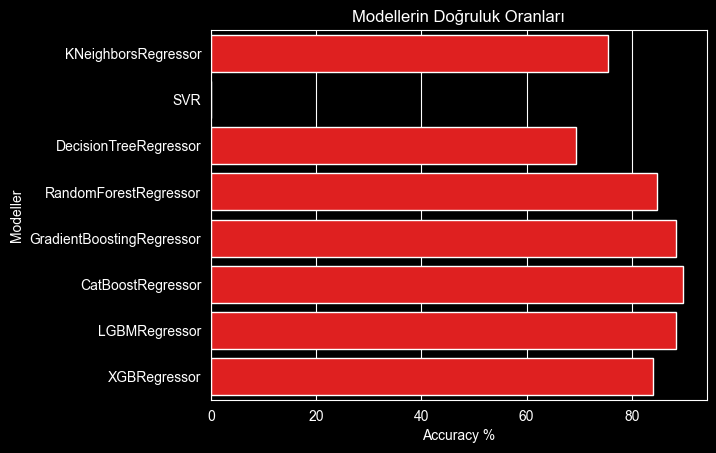

In [47]:
sns.barplot(x= 'Accuracy', y = 'Modeller', data=sonuclar, color="r")
plt.xlabel('Accuracy %')
plt.title('Modellerin Doğruluk Oranları');

In [48]:
sonuclar

,Modeller,Accuracy
0,KNeighborsRegressor,75.471642
1,SVR,0.022538
2,DecisionTreeRegressor,69.419325
3,RandomForestRegressor,84.78707
4,GradientBoostingRegressor,88.452993
5,CatBoostRegressor,89.770021
6,LGBMRegressor,88.291435
7,XGBRegressor,84.107053


In [49]:
catb_params = {'depth'         : [4,5,6],
               'learning_rate' : [0.03, 0.05, 0.1],
               'iterations'    : [30, 50, 100, 500,1000,800],
               "l2_leaf_reg"   : [3,5,7,10]
}

catb_cv = RandomizedSearchCV(catb_model, catb_params, cv = 5, verbose = 2, n_jobs = -1).fit(x_train_scaled, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
0:	learn: 105042.7121932	total: 330us	remaining: 165ms
1:	learn: 99256.1013029	total: 615us	remaining: 153ms
2:	learn: 93307.1950006	total: 874us	remaining: 145ms
3:	learn: 89130.4266904	total: 1.13ms	remaining: 140ms
4:	learn: 84646.7304266	total: 1.39ms	remaining: 138ms
5:	learn: 80549.5864102	total: 1.65ms	remaining: 136ms
6:	learn: 77023.4811375	total: 1.9ms	remaining: 133ms
7:	learn: 73032.2944692	total: 2.14ms	remaining: 132ms
8:	learn: 69897.2941272	total: 2.4ms	remaining: 131ms
9:	learn: 66964.1598155	total: 2.64ms	remaining: 130ms
10:	learn: 64427.4948314	total: 2.89ms	remaining: 129ms
11:	learn: 61844.7027422	total: 3.15ms	remaining: 128ms
12:	learn: 59346.3244732	total: 3.4ms	remaining: 127ms
13:	learn: 57480.0342891	total: 3.65ms	remaining: 127ms
14:	learn: 55210.8096062	total: 3.91ms	remaining: 126ms
15:	learn: 53560.5090439	total: 4.16ms	remaining: 126ms
16:	learn: 52161.3172613	total: 4.4ms	remaining: 125ms
17:

In [50]:
catb_cv.best_params_

{'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 4}

In [51]:
catb_tuned = CatBoostRegressor(learning_rate = 0.03, iterations = 800, depth = 5, l2_leaf_reg = 7).fit(x_train_scaled, y_train)

0:	learn: 110521.7942629	total: 690us	remaining: 551ms
1:	learn: 109024.1573868	total: 1.14ms	remaining: 456ms
2:	learn: 107313.0990649	total: 1.52ms	remaining: 403ms
3:	learn: 105689.2003706	total: 1.89ms	remaining: 375ms
4:	learn: 103816.5758059	total: 2.25ms	remaining: 357ms
5:	learn: 102325.0536765	total: 2.63ms	remaining: 348ms
6:	learn: 100533.0325535	total: 3.01ms	remaining: 341ms
7:	learn: 99165.8749271	total: 3.39ms	remaining: 336ms
8:	learn: 97665.6748895	total: 3.76ms	remaining: 330ms
9:	learn: 96260.9903592	total: 4.13ms	remaining: 326ms
10:	learn: 95061.8635746	total: 4.33ms	remaining: 311ms
11:	learn: 93539.6690731	total: 4.7ms	remaining: 309ms
12:	learn: 92065.1870592	total: 5.08ms	remaining: 308ms
13:	learn: 90765.1240959	total: 5.5ms	remaining: 309ms
14:	learn: 89571.8236655	total: 5.88ms	remaining: 308ms
15:	learn: 88218.4019508	total: 6.27ms	remaining: 307ms
16:	learn: 86898.4909243	total: 6.64ms	remaining: 306ms
17:	learn: 85758.9485866	total: 7ms	remaining: 304ms
1

In [52]:
y_pred = catb_tuned.predict(x_test_scaled)
r_kare = r2_score(y_test, y_pred) *100

In [53]:
r_kare

90.82862735510966